In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

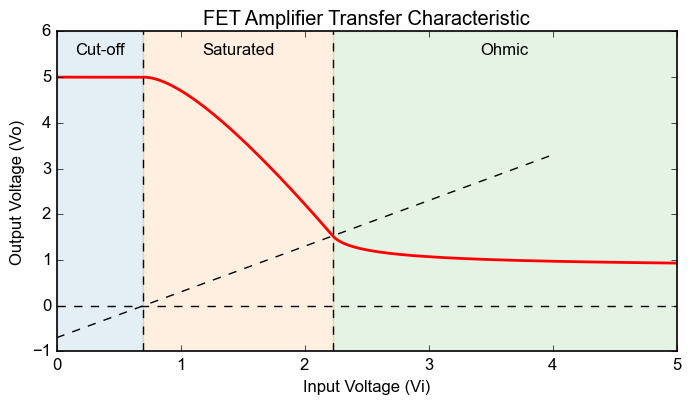

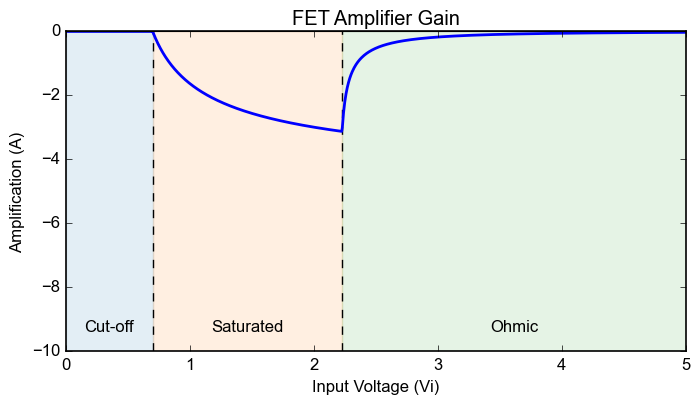

In [30]:
Vdd = 5
Rd = 10
Rs = 2
Vt = 0.7
alpha = 1
Vimax = Vt + (-Rd + Rs*(Rd + Rs)*alpha*Vdd + Rd*np.sqrt(1 + 2 * alpha * Vdd*(Rd + Rs))) / (alpha*(Rd + Rs)**2)



Vi = np.linspace(0, 5, 1000)

Vo = np.empty_like(Vi)

mask_low = Vi < Vt
mask_mid = (Vi >= Vt) & (Vi < Vimax)
mask_high = Vi >= Vimax

Vo[mask_low] = Vdd
Vo[mask_mid] = Vdd - Rd/(alpha*Rs**2) *((Vi[mask_mid] - Vt)*alpha*Rs + 1 - np.sqrt(1 + 2 * alpha * Rs * (Vi[mask_mid] - Vt)))
Vo[mask_high] = (
    Rd
    - Rs**2 * Vdd * alpha
    + Rd * Rs * (Vi[mask_high] - Vt) * alpha
    - Rd**2
    * (
        -Vi[mask_high] * alpha
        + Vt * alpha
        + np.sqrt(
            (1 / Rd**2)
            * (
                1
                + alpha
                * (
                    -2 * Rd * Vdd
                    + 2 * Rd * Vi[mask_high]
                    + 2 * Rs * Vi[mask_high]
                    - 2 * (Rd + Rs) * Vt
                    + (
                        Rd * (-Vi[mask_high] + Vt)
                        + Rs * (Vdd - Vi[mask_high] + Vt)
                    )**2
                    * alpha
                )
            )
        )
    )
) / ((Rd - Rs) * (Rd + Rs) * alpha)

plt.figure(figsize=(8, 4))
plt.axvspan(0, Vt, color='tab:blue', alpha=0.12)
plt.axvspan(Vt, Vimax, color='tab:orange', alpha=0.12)
plt.axvspan(Vimax, 5, color='tab:green', alpha=0.12)
plt.axvline(Vt, color='black', linestyle='--', linewidth=1)
plt.axvline(Vimax, color='black', linestyle='--', linewidth=1)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.plot([0, 4], [-Vt, 4 - Vt], color='black', linestyle='--', linewidth=1)
plt.plot(Vi, Vo, lw=2, color='red', zorder=2)
plt.text(Vt / 2, 5.75, 'Cut-off', ha='center', va='top')
plt.text((Vt + Vimax) / 2, 5.75, 'Saturated', ha='center', va='top')
plt.text((Vimax + 5) / 2, 5.75, 'Ohmic', ha='center', va='top')
plt.xlabel('Input Voltage (Vi)')
plt.ylabel('Output Voltage (Vo)')
plt.xlim(0, 5)
plt.ylim(-1, 6)
plt.title('FET Amplifier Transfer Characteristic')
plt.show()

A = np.diff(Vo) / np.diff(Vi)
Vi_A = 0.5 * (Vi[:-1] + Vi[1:])

plt.figure(figsize=(8, 4))
plt.axvspan(0, Vt, color='tab:blue', alpha=0.12)
plt.axvspan(Vt, Vimax, color='tab:orange', alpha=0.12)
plt.axvspan(Vimax, 5, color='tab:green', alpha=0.12)
plt.axvline(Vt, color='black', linestyle='--', linewidth=1)
plt.axvline(Vimax, color='black', linestyle='--', linewidth=1)
plt.plot(Vi_A, A, lw=2, color='blue')
plt.text(Vt / 2, -9, 'Cut-off', ha='center', va='top')
plt.text((Vt + Vimax) / 2, -9, 'Saturated', ha='center', va='top')
plt.text((Vimax + 5) / 2, -9, 'Ohmic', ha='center', va='top')
plt.xlabel('Input Voltage (Vi)')
plt.ylabel('Amplification (A)')
plt.xlim(0, 5)
plt.ylim(-10, 0)
plt.title('FET Amplifier Gain')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

In [31]:
print(Vimax)
Amax = np.min(A)
Amax_theo = -(np.sqrt(1 + 2 * alpha * Rd * Vdd) - 1) 
print(Amax)
print(Amax_theo)

2.227777777777778
-3.1233874484657074
-9.04987562112089
